In [1]:
import os
import json
import shutil
import random
import getpass
import warnings
import collections
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR100, FashionMNIST
from torch.utils.data import DataLoader

In [2]:
#for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
#For saving files and datasets
DATA_ROOT   = Path("./data")
FIGURES_DIR = Path("./figures")
DATA_ROOT.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device: {DEVICE}")

[INFO] Device: cpu


In [5]:
BATCH_SIZE   = 128
NUM_WORKERS  = 2
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

In [6]:
#saving eda figures
def save_fig(name: str):
    path = FIGURES_DIR / f"{name}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")

In [7]:
def get_labels(dataset) -> list:
    if hasattr(dataset, "targets"):
        targets = dataset.targets
        if isinstance(targets, torch.Tensor):
            return targets.tolist()          # tensor([0,1,2,...]) → [0, 1, 2, ...]
        return [int(t) for t in targets]     # handles any other iterable
    return [int(dataset[i][1]) for i in range(len(dataset))]

In [8]:
#returns mean and std of the images in dataset
def pixel_stats(dataset, n_samples: int = 2000, label: str = ""):
    indices = random.sample(range(len(dataset)), min(n_samples, len(dataset)))
    stack   = np.stack([dataset[i][0].numpy() for i in indices])   
    if stack.ndim == 3:                                             
        stack = stack[:, np.newaxis]
    mean = stack.mean(axis=(0, 2, 3))
    std  = stack.std(axis=(0, 2, 3))
    print(f"  [{label}] mean={np.round(mean,4)}  std={np.round(std,4)}")
    return mean, std

In [9]:
#Shows a small sample grid of the images used as sample from each class
def show_sample_grid(dataset, class_names: list, n_classes: int = 10,
                     n_cols: int = 5, title: str = "", fname: str = "grid"):
    label2idx = collections.defaultdict(list)
    for idx, lbl in enumerate(get_labels(dataset)):
        label2idx[lbl].append(idx)

    chosen = random.sample(range(len(class_names)), min(n_classes, len(class_names)))
    fig, axes = plt.subplots(len(chosen), n_cols,
                             figsize=(n_cols * 1.6, len(chosen) * 1.6))
    if len(chosen) == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=12, fontweight="bold")

    for row, cls in enumerate(chosen):
        idxs = random.sample(label2idx[cls], min(n_cols, len(label2idx[cls])))
        for col, idx in enumerate(idxs):
            t   = dataset[idx][0]
            img = t.permute(1, 2, 0).numpy()
            img = np.clip(img, 0, 1)
            ax  = axes[row][col]
            ax.imshow(img if img.shape[2] == 3 else img[:, :, 0], cmap="gray")
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(class_names[cls], fontsize=7,
                              rotation=0, labelpad=55, va="center")
    plt.tight_layout()
    save_fig(fname)
    plt.show()

In [10]:
#Class distribution graph
def plot_class_distribution(counts: dict, class_names: list,
                             title: str, fname: str):
    ids    = list(range(len(class_names)))
    values = [counts.get(i, 0) for i in ids]
    fig, ax = plt.subplots(figsize=(max(10, len(ids) // 4), 4))
    ax.bar(ids, values, color="steelblue", width=0.8)
    mean_val = np.mean(values)
    ax.axhline(mean_val, color="red", linestyle="--",
               label=f"Mean = {mean_val:.0f}")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Class ID")
    ax.set_ylabel("Sample Count")
    ax.legend()
    plt.tight_layout()
    save_fig(fname)
    plt.show()

In [11]:
#Histogram between the frequency of each image and colour
def plot_pixel_histograms(dataset, n_samples: int = 500,
                          n_channels: int = 3, title: str = "", fname: str = "hist"):
    channel_names = ["Red", "Green", "Blue"] if n_channels == 3 else ["Gray"]
    colors        = ["#e74c3c", "#2ecc71", "#3498db"] if n_channels == 3 else ["#8e44ad"]

    pixel_vals = {c: [] for c in range(n_channels)}
    for i in random.sample(range(len(dataset)), min(n_samples, len(dataset))):
        img = dataset[i][0].numpy()               # (C,H,W)
        for c in range(n_channels):
            pixel_vals[c].extend(img[c].flatten().tolist())

    fig, axes = plt.subplots(1, n_channels, figsize=(5 * n_channels, 4), sharey=True)
    if n_channels == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=11, fontweight="bold")
    for c, ax in enumerate(axes):
        ax.hist(pixel_vals[c], bins=50, color=colors[c], alpha=0.75, edgecolor="none")
        ax.axvline(np.mean(pixel_vals[c]), color="black", linestyle="--",
                   label=f"μ={np.mean(pixel_vals[c]):.3f}")
        ax.set_title(channel_names[c])
        ax.set_xlabel("Pixel Value [0, 1]")
        ax.legend(fontsize=8)
    axes[0].set_ylabel("Frequency")
    plt.tight_layout()
    save_fig(fname)
    plt.show()

In [12]:
def plot_mean_images(dataset, class_names: list, n_show: int,
                     title: str, fname: str, cmap: str = "viridis"):
    label2imgs = collections.defaultdict(list)
    for img, lbl in dataset:
        if lbl < n_show:
            label2imgs[lbl].append(img.numpy())

    cols = 5
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2))
    axes = axes.flatten()
    fig.suptitle(title, fontsize=12, fontweight="bold")
    for cls in range(n_show):
        mean = np.mean(label2imgs[cls], axis=0)
        mean = np.clip(mean.transpose(1, 2, 0) if mean.ndim == 3 else mean, 0, 1)
        axes[cls].imshow(mean if mean.ndim == 3 and mean.shape[2] == 3
                         else mean.squeeze(), cmap=cmap)
        axes[cls].set_title(class_names[cls], fontsize=7)
        axes[cls].axis("off")
    for ax in axes[n_show:]:
        ax.axis("off")
    plt.tight_layout()
    save_fig(fname)
    plt.show()

We start with the baseline dataset of CIFAR-100

  Train : 50,000 | Test : 10,000 | Classes : 100
  Image shape : (3, 32, 32)  (C, H, W)


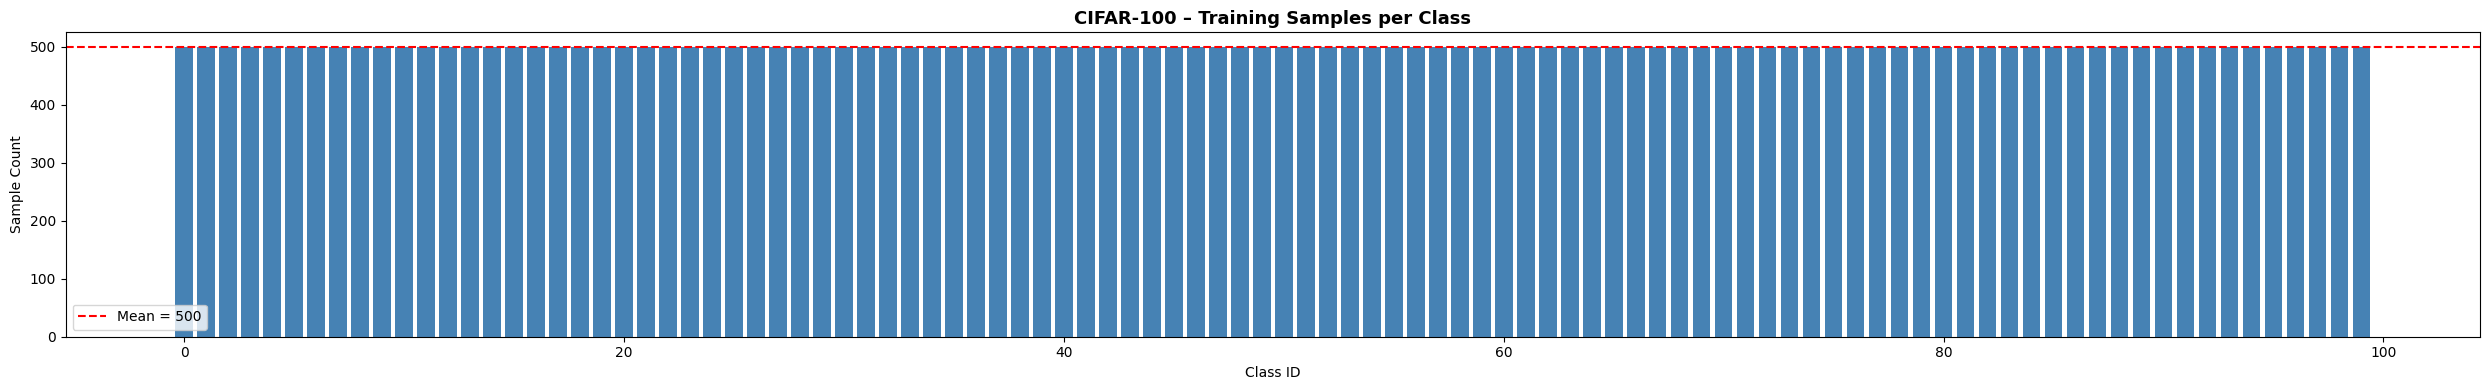

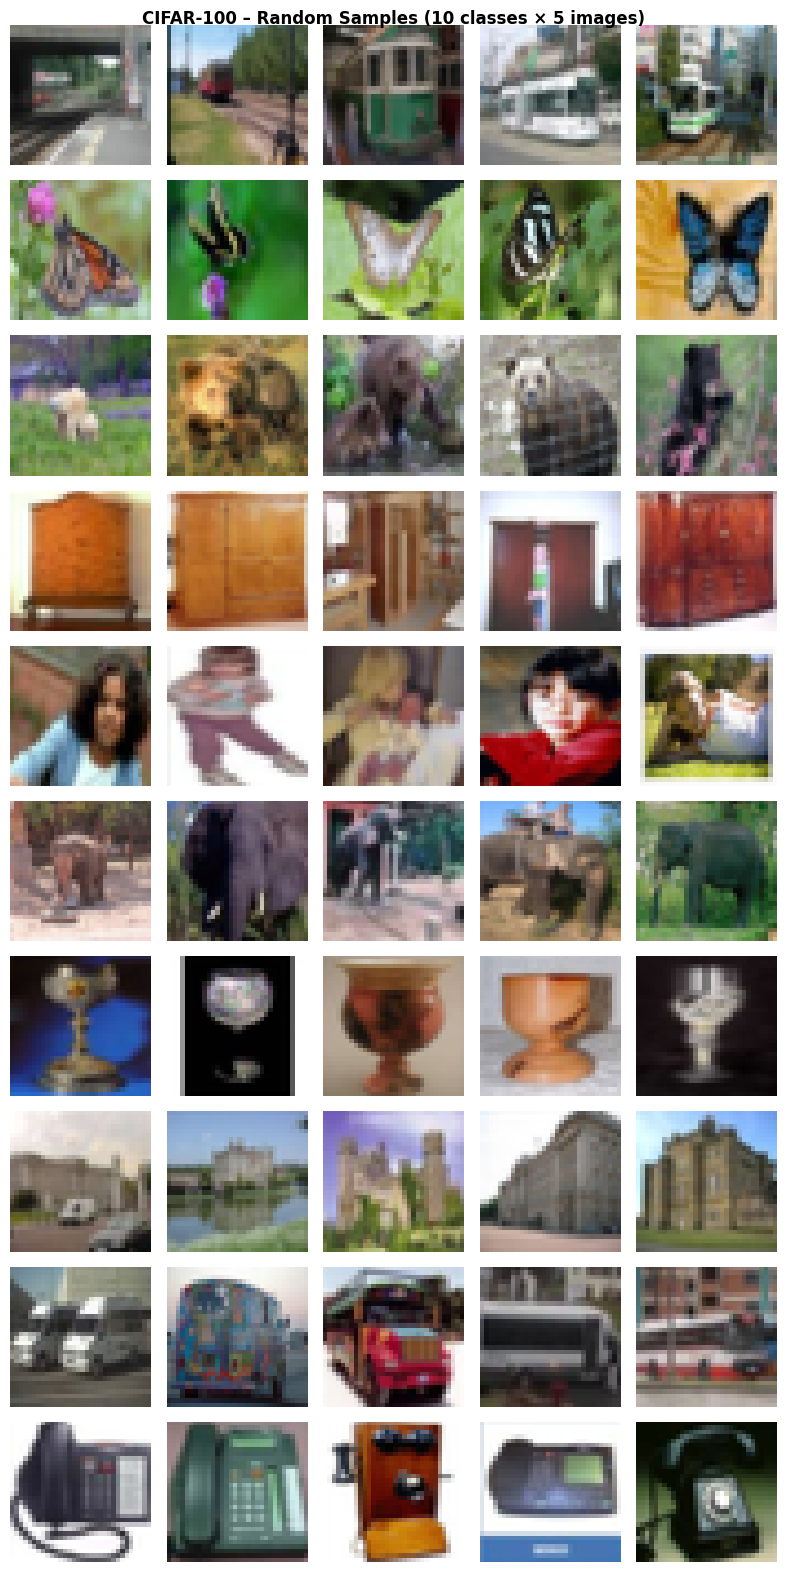


[CIFAR-100] Pixel statistics:
  [train] mean=[0.5127 0.4883 0.4385]  std=[0.2671 0.2579 0.2771]


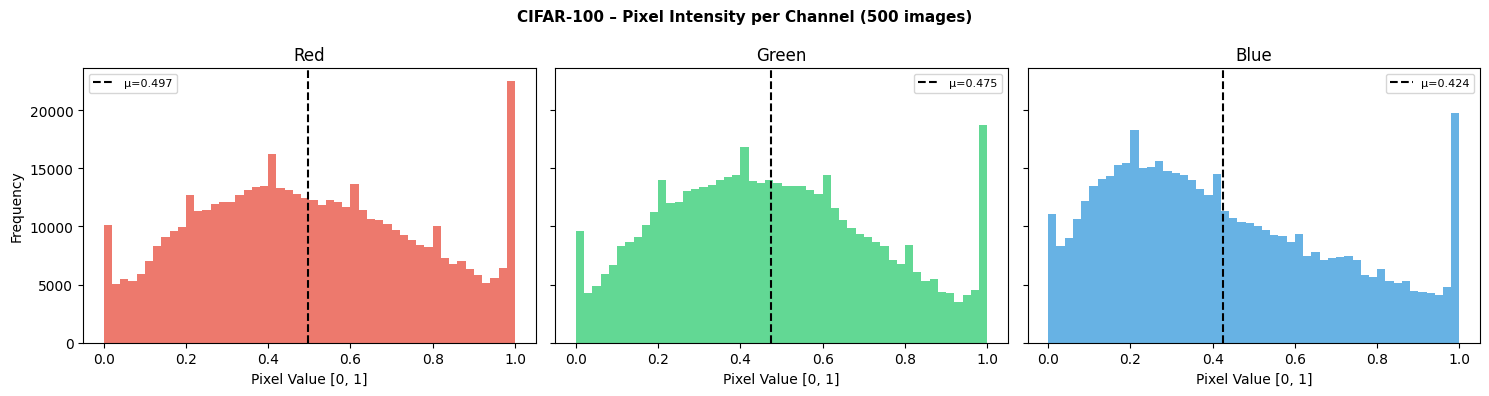

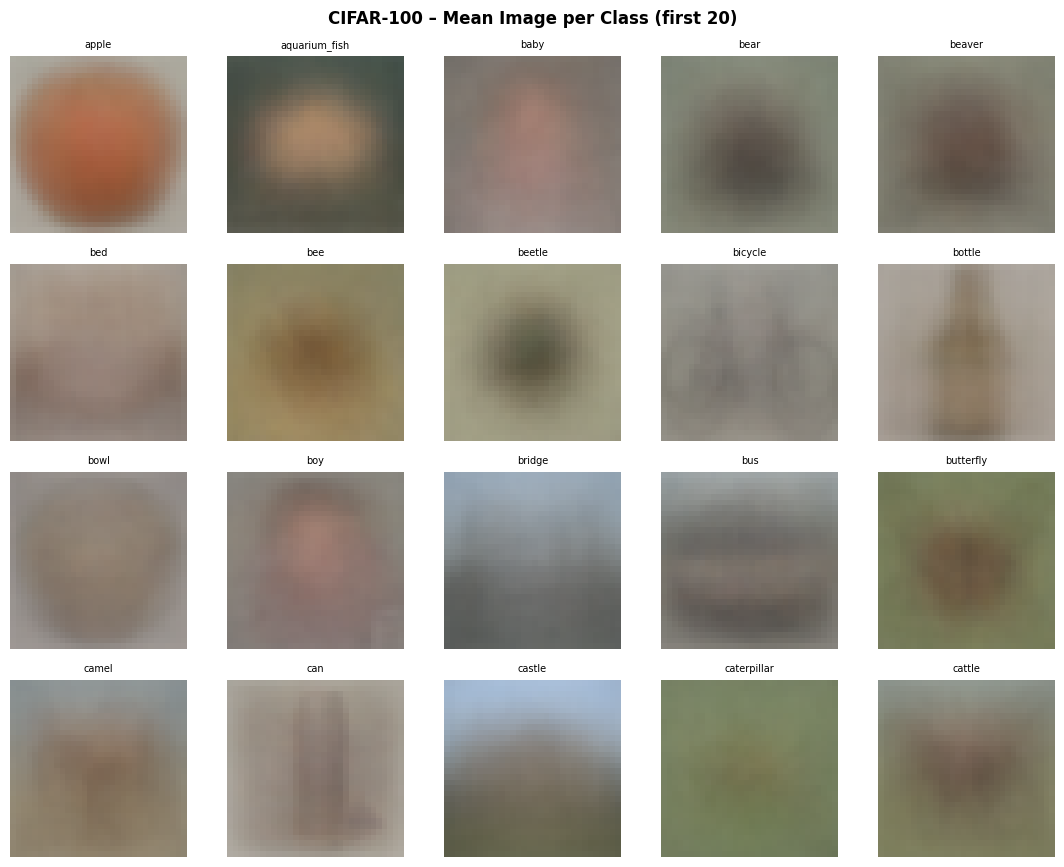

/Users/omkarsmacbook/Desktop/Machine-Learning-Assignments/Project/NoMasBlackBox/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)



[CIFAR-100] Loader ready — batch shape: (128, 3, 224, 224)


In [13]:
_to_tensor = transforms.ToTensor()

cifar100_train_raw = CIFAR100(DATA_ROOT/"cifar100", train=True,
                               download=True, transform=_to_tensor)
cifar100_test_raw  = CIFAR100(DATA_ROOT/"cifar100", train=False,
                               download=True, transform=_to_tensor)
cifar100_classes   = cifar100_train_raw.classes   # 100 fine-grained labels

print(f"  Train : {len(cifar100_train_raw):,} | Test : {len(cifar100_test_raw):,} | Classes : 100")
print(f"  Image shape : {tuple(cifar100_train_raw[0][0].shape)}  (C, H, W)")

#Class distribution 
train_counts_c100 = collections.Counter(get_labels(cifar100_train_raw))
plot_class_distribution(
    train_counts_c100, cifar100_classes,
    title="CIFAR-100 – Training Samples per Class",
    fname="cifar100_class_distribution"
)

#Sample grid
show_sample_grid(
    cifar100_train_raw, cifar100_classes,
    n_classes=10, n_cols=5,
    title="CIFAR-100 – Random Samples (10 classes × 5 images)",
    fname="cifar100_sample_grid"
)

# Pixel statistics & histograms 
print("\n[CIFAR-100] Pixel statistics:")
c100_mean, c100_std = pixel_stats(cifar100_train_raw, n_samples=3000, label="train")
plot_pixel_histograms(
    cifar100_train_raw, n_samples=500, n_channels=3,
    title="CIFAR-100 – Pixel Intensity per Channel (500 images)",
    fname="cifar100_pixel_histograms"
)

# Mean image per class (first 20) 
plot_mean_images(
    cifar100_train_raw, cifar100_classes, n_show=20,
    title="CIFAR-100 – Mean Image per Class (first 20)",
    fname="cifar100_mean_images", cmap="viridis"
)

# Final normalised DataLoaders (NO augmentation — Milestone 1 baseline)
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD  = (0.2675, 0.2565, 0.2761)

_cifar100_tf = transforms.Compose([
    transforms.Resize((224, 224)), #Resizing the images to fit the requirements of the model
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

cifar100_train_ds = CIFAR100(DATA_ROOT/"cifar100", train=True,
                              download=False, transform=_cifar100_tf)
cifar100_test_ds  = CIFAR100(DATA_ROOT/"cifar100", train=False,
                              download=False, transform=_cifar100_tf)

cifar100_train_loader = DataLoader(cifar100_train_ds, batch_size=BATCH_SIZE,
                                    shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
cifar100_test_loader  = DataLoader(cifar100_test_ds,  batch_size=BATCH_SIZE,
                                    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

_b, _l = next(iter(cifar100_train_loader))
print(f"\n[CIFAR-100] Loader ready — batch shape: {tuple(_b.shape)}")

  Train : 60,000 | Test : 10,000 | Classes : 10
  Image shape : (1, 28, 28)  (C, H, W)


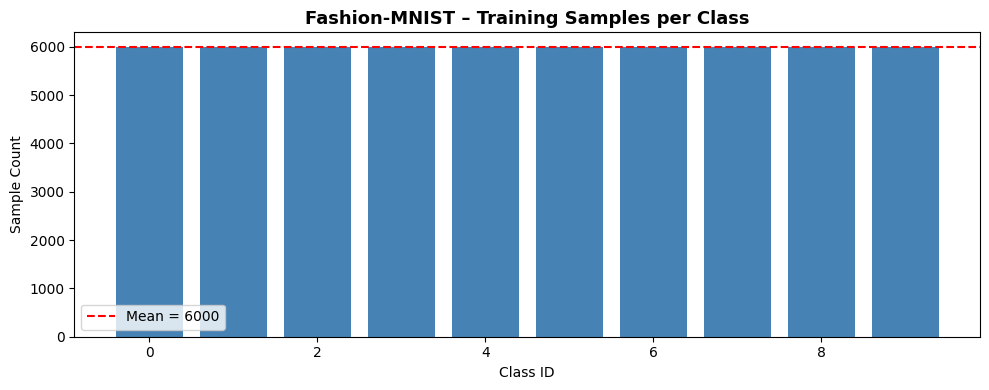

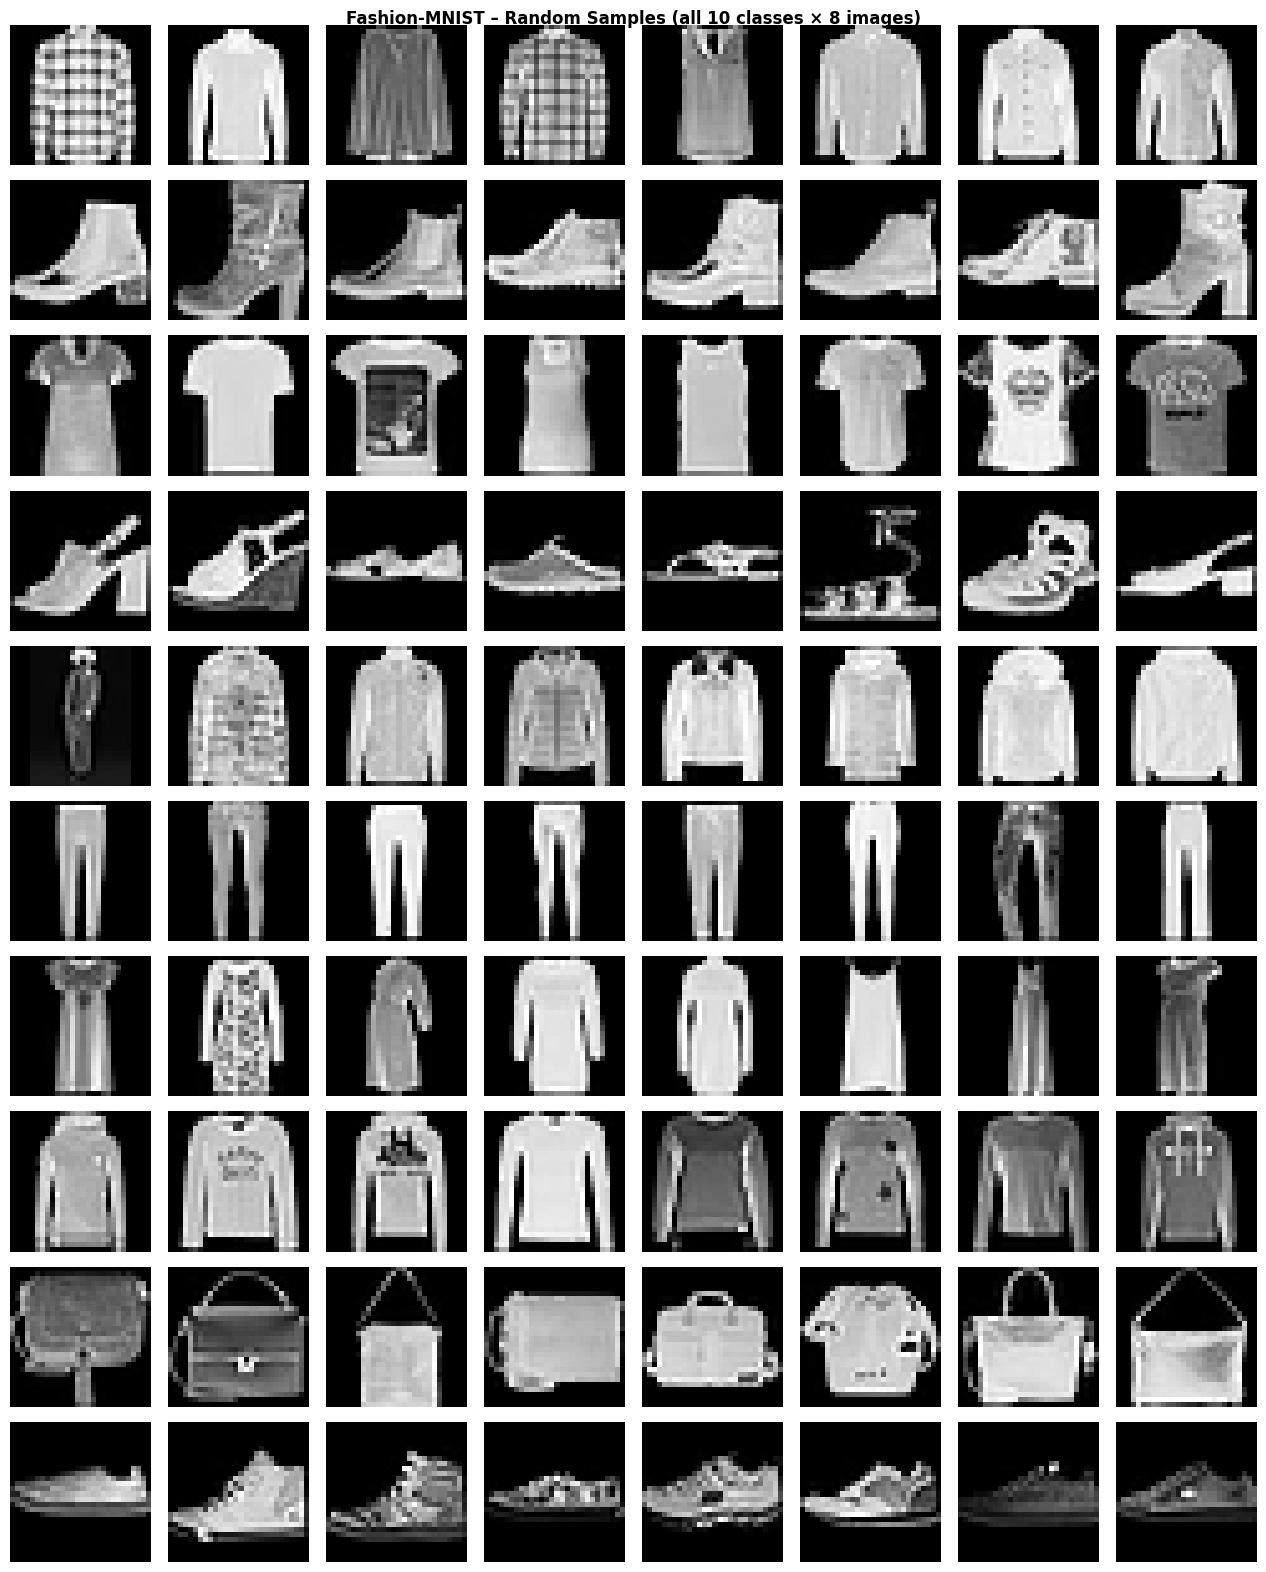


[Fashion-MNIST] Pixel statistics:
  [train] mean=[0.2868]  std=[0.3547]


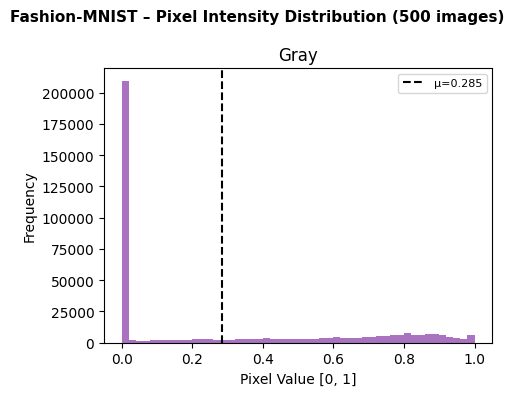

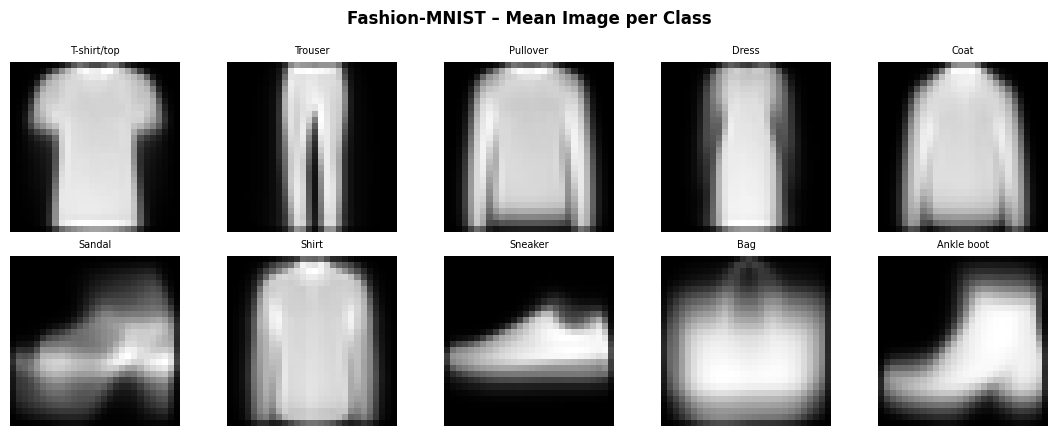

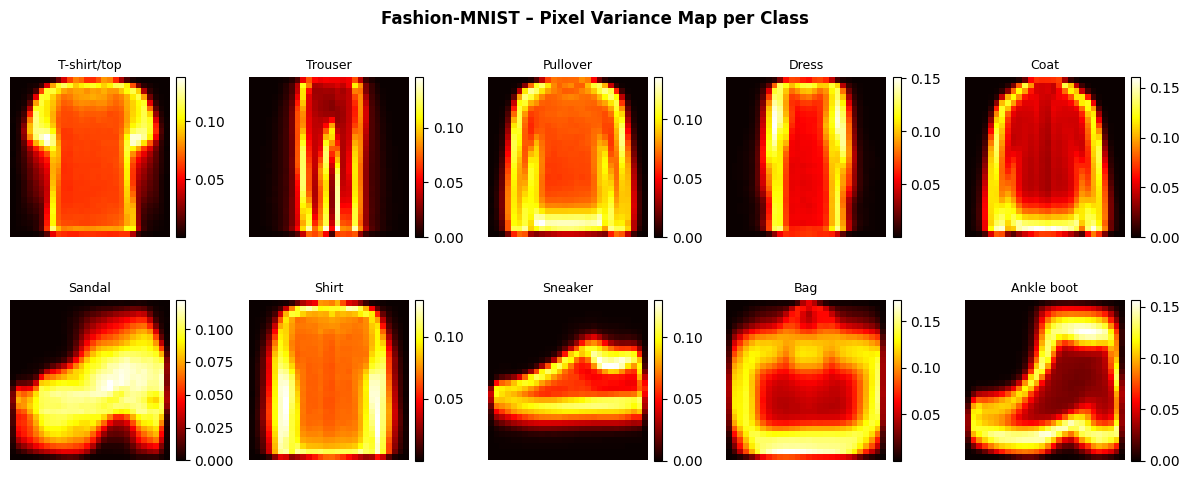

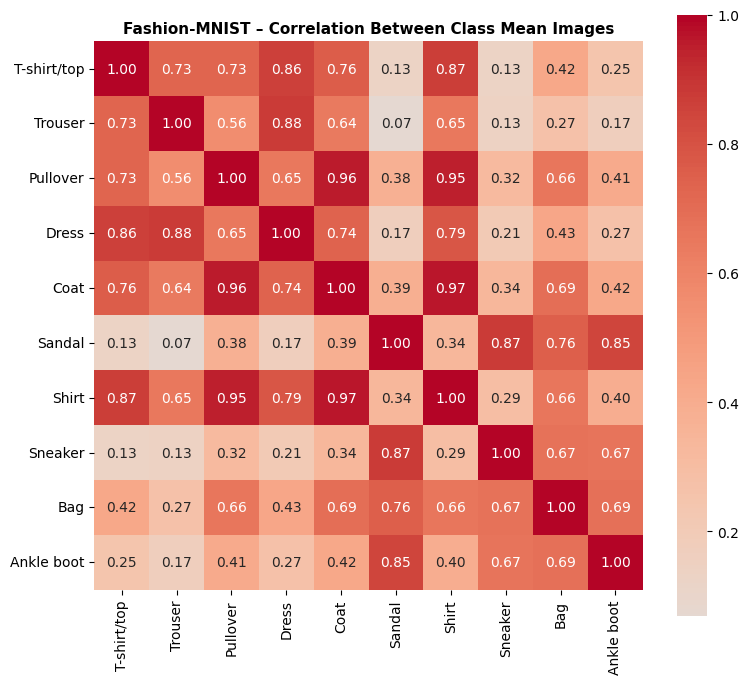

/Users/omkarsmacbook/Desktop/Machine-Learning-Assignments/Project/NoMasBlackBox/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)



[Fashion-MNIST] Loader ready — batch shape: (128, 3, 224, 224)


In [14]:
#Fashion dataset starting with raw data to eda before resizing

fmnist_train_raw = FashionMNIST(DATA_ROOT/"fmnist", train=True,
                                 download=True, transform=_to_tensor)
fmnist_test_raw  = FashionMNIST(DATA_ROOT/"fmnist", train=False,
                                 download=True, transform=_to_tensor)
fmnist_classes   = ["T-shirt/top","Trouser","Pullover","Dress","Coat",
                     "Sandal","Shirt","Sneaker","Bag","Ankle boot"]

print(f"  Train : {len(fmnist_train_raw):,} | Test : {len(fmnist_test_raw):,} | Classes : 10")
print(f"  Image shape : {tuple(fmnist_train_raw[0][0].shape)}  (C, H, W)")

# Class distribution
train_counts_fm = collections.Counter(get_labels(fmnist_train_raw))
plot_class_distribution(
    train_counts_fm, fmnist_classes,
    title="Fashion-MNIST – Training Samples per Class",
    fname="fmnist_class_distribution"
)

# Sample grid 
show_sample_grid(
    fmnist_train_raw, fmnist_classes,
    n_classes=10, n_cols=8,
    title="Fashion-MNIST – Random Samples (all 10 classes × 8 images)",
    fname="fmnist_sample_grid"
)

# Pixel statistics & histogram 
print("\n[Fashion-MNIST] Pixel statistics:")
fm_mean, fm_std = pixel_stats(fmnist_train_raw, n_samples=3000, label="train")
plot_pixel_histograms(
    fmnist_train_raw, n_samples=500, n_channels=1,
    title="Fashion-MNIST – Pixel Intensity Distribution (500 images)",
    fname="fmnist_pixel_histogram"
)

# Mean image per class 
plot_mean_images(
    fmnist_train_raw, fmnist_classes, n_show=10,
    title="Fashion-MNIST – Mean Image per Class",
    fname="fmnist_mean_images", cmap="gray"
)

# Pixel variance map per class (shows spatial complexity)
label2imgs_fm = collections.defaultdict(list)
for img, lbl in fmnist_train_raw:
    label2imgs_fm[lbl].append(img.squeeze().numpy())

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Fashion-MNIST – Pixel Variance Map per Class", fontsize=12, fontweight="bold")
for cls in range(10):
    ax  = axes[cls // 5][cls % 5]
    var = np.var(label2imgs_fm[cls], axis=0)
    im  = ax.imshow(var, cmap="hot")
    ax.set_title(fmnist_classes[cls], fontsize=9)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
save_fig("fmnist_variance_maps")
plt.show()

# Inter-class correlation heatmap 
mean_vectors = np.array([
    np.mean(label2imgs_fm[cls], axis=0).flatten() for cls in range(10)
])
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(np.corrcoef(mean_vectors), annot=True, fmt=".2f",
            xticklabels=fmnist_classes, yticklabels=fmnist_classes,
            cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Fashion-MNIST – Correlation Between Class Mean Images",
             fontsize=11, fontweight="bold")
plt.tight_layout()
save_fig("fmnist_class_correlation")
plt.show()

# Final DataLoaders
_fmnist_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

fmnist_train_ds = FashionMNIST(DATA_ROOT/"fmnist", train=True,
                                download=False, transform=_fmnist_tf)
fmnist_test_ds  = FashionMNIST(DATA_ROOT/"fmnist", train=False,
                                download=False, transform=_fmnist_tf)

fmnist_train_loader = DataLoader(fmnist_train_ds, batch_size=BATCH_SIZE,
                                  shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
fmnist_test_loader  = DataLoader(fmnist_test_ds,  batch_size=BATCH_SIZE,
                                  shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

_b, _l = next(iter(fmnist_train_loader))
print(f"\n[Fashion-MNIST] Loader ready — batch shape: {tuple(_b.shape)}")

In [15]:
#Download dataset using kagglehub (skipped if already present)
PLANT_BASE      = DATA_ROOT / "plant_diseases" / "plant_disease_data"
PLANT_TRAIN_DIR = PLANT_BASE / "train"
PLANT_VALID_DIR = PLANT_BASE / "valid"

if PLANT_TRAIN_DIR.exists() and PLANT_VALID_DIR.exists():
    print("Dataset already present, skipping download")
else:
    try:
        import kagglehub
    except ImportError:
        import subprocess
        import sys
        print("Installing kagglehub...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
        import kagglehub
    
    print("Downloading dataset using kagglehub... (this may take a few minutes)")
    path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
    print("Download complete. Setting up directory structure...")
    
    original = Path(path) / "New Plant Diseases Dataset(Augmented)" / "New Plant Diseases Dataset(Augmented)"
    
    if original.exists():
        if not PLANT_BASE.exists():
            import shutil
            PLANT_BASE.parent.mkdir(parents=True, exist_ok=True)
            shutil.copytree(original, PLANT_BASE)
        print("Dataset setup complete.")
    else:
        print(f"Warning: Could not find expected directory structure at {original}")

#Load & EDA
PLANT_LOADED = PLANT_TRAIN_DIR.exists() and PLANT_VALID_DIR.exists()

if PLANT_LOADED:
    plant_train_raw = torchvision.datasets.ImageFolder(
        str(PLANT_TRAIN_DIR), transform=transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
        ])
    )
    plant_valid_raw = torchvision.datasets.ImageFolder(
        str(PLANT_VALID_DIR), transform=transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
        ])
    )
    plant_classes = plant_train_raw.classes   # 38 classes

    print(f"Train : {len(plant_train_raw):,} | Valid : {len(plant_valid_raw):,} | Classes : {len(plant_classes)}")

    # Class distribution
    train_counts_pl = collections.Counter(get_labels(plant_train_raw))
    plot_class_distribution(
        train_counts_pl, plant_classes,
        title="Plant Diseases – Training Samples per Class",
        fname="plant_class_distribution"
    )

    # Samples per host plant (everything before ___)
    host_counts = collections.Counter()
    for name, count in train_counts_pl.items():
        host = plant_classes[name].split("___")[0]
        host_counts[host] += count

    fig, ax = plt.subplots(figsize=(12, 5))
    hosts  = list(host_counts.keys())
    values = [host_counts[h] for h in hosts]
    ax.bar(hosts, values, color="#f39c12", edgecolor="white")
    ax.set_title("Plant Diseases – Training Samples per Host Plant",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Host Plant")
    ax.set_ylabel("Training Samples")
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    save_fig("plant_samples_per_host")
    plt.show()

    # Sample grid (8 random classes)
    show_sample_grid(
        plant_train_raw, plant_classes,
        n_classes=8, n_cols=5,
        title="Plant Diseases – Random Samples (8 classes × 5 images)",
        fname="plant_sample_grid"
    )

    # Pixel statistics & histograms
    print("\n[Plant Diseases] Pixel statistics:")
    pl_mean, pl_std = pixel_stats(plant_train_raw, n_samples=2000, label="train")
    plot_pixel_histograms(
        plant_train_raw, n_samples=300, n_channels=3,
        title="Plant Diseases – Pixel Intensity per Channel (300 images)",
        fname="plant_pixel_histograms"
    )

    # Image size consistency check
    print("\n[Plant Diseases] Image size check (200 samples):")
    from PIL import Image as PILImage
    size_counts = collections.Counter()
    for i in random.sample(range(len(plant_train_raw)), min(200, len(plant_train_raw))):
        with PILImage.open(plant_train_raw.imgs[i][0]) as im:
            size_counts[im.size] += 1
    for size, cnt in size_counts.most_common(5):
        print(f"    {size[0]}×{size[1]} px — {cnt} images")

    # Final DataLoaders (224×224 for VGG16 / ResNet18)
    _plant_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    plant_train_ds = torchvision.datasets.ImageFolder(str(PLANT_TRAIN_DIR), transform=_plant_tf)
    plant_valid_ds = torchvision.datasets.ImageFolder(str(PLANT_VALID_DIR), transform=_plant_tf)

    plant_train_loader = DataLoader(plant_train_ds, batch_size=32,
                                     shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
    plant_valid_loader = DataLoader(plant_valid_ds, batch_size=32,
                                     shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    _b, _l = next(iter(plant_train_loader))
    print(f"\n[Plant Diseases] Loader ready — batch shape: {tuple(_b.shape)}")

else:
    print("  [WARN] Plant Diseases dataset not found. Dataset download may have failed.")
    print("         Check your internet connection and re-run.")


Installing kagglehub...


/Users/omkarsmacbook/Desktop/Machine-Learning-Assignments/Project/NoMasBlackBox/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/omkarsmacbook/Desktop/Machine-Learning-Assignments/Project/NoMasBlackBox/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Download complete. Setting up directory structure...
Dataset setup complete.
  [WARN] Plant Diseases dataset not found. Dataset download may have failed.
         Check your internet connection and re-run.
